# Winoground / Evaluating CLIP — Defensa MCC225
**Niels Victor Pacheco Barrios** · Cuadernos **C5, C8, C10**

## ¿Qué hacemos aquí, en una frase?
Medimos si un modelo tipo **CLIP**, que recupera imágenes muy bien, de verdad **razona de forma composicional**. Usamos **Winoground**: pares de dos imágenes y dos frases con *las mismas palabras en distinto orden*.

**Tesis:** un **retrieval alto no implica composición**. Lo vamos a ver con números: el modelo recupera bien (Recall@K alto) pero su **group score queda cerca del azar**.

Reutilizamos el motor **OpenCLIP del Cuaderno 10** y explicamos el *porqué* con la fusión profunda (**C5**) y la atención crossmodal (**C8**).

> Cómo leer este notebook: cada sección tiene 2-3 líneas de explicación y luego el código que la respalda. Al final están **respondidas las 5 preguntas**.

## 1. Entorno (hoja de trazabilidad)
Antes de cualquier resultado, registramos versiones, revisión de git y dispositivo. Esto hace el experimento **reproducible y trazable**.

In [1]:
import os, sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name=='notebooks' else pathlib.Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
from src.env_logging import print_snapshot
_ = print_snapshot(ROOT)

/Users/nielspacheco/Desktop/Classes/UNI/Maestria en ciencias Computacion/IA generativa y multimodal/MCC225-ExamenParcial-Winoground/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HOJA DE TRAZABILIDAD — ENTORNO DE EJECUCIÓN (MCC225)
           python : 3.12.11
         platform : macOS-26.1-arm64-arm-64bit
     git_revision : e22ab9c
           device : mps (Apple Silicon)
            torch : 2.5.1
  open_clip_torch : 3.3.0
     transformers : 5.12.0
         datasets : 5.0.0
            numpy : 2.1.3
            faiss : 1.14.3


## 2. El problema: el par mínimo de Winoground
Cada ejemplo tiene **2 imágenes** y **2 captions** con el **mismo vocabulario** en distinto orden. Para acertar hay que entender *quién hace qué a quién*, no solo reconocer objetos. Veamos un par real.

In [2]:
from src.winoground_data import load_dataset
examples, source = load_dataset(prefer_real=True)
print('fuente:', source, '| N =', len(examples))
ex = examples[0]
print('caption_0:', ex.caption_0)
print('caption_1:', ex.caption_1)

fuente: winoground_real | N = 400
caption_0: an old person kisses a young person
caption_1: a young person kisses an old person


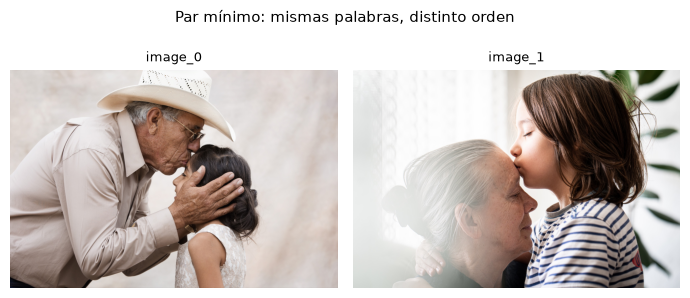

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(7, 3.2))
ax[0].imshow(ex.image_0); ax[0].set_title('image_0', fontsize=9); ax[0].axis('off')
ax[1].imshow(ex.image_1); ax[1].set_title('image_1', fontsize=9); ax[1].axis('off')
plt.suptitle('Par mínimo: mismas palabras, distinto orden', fontsize=11)
plt.tight_layout(); plt.show()

### Las tres métricas (definición)
Con la matriz $2\times2$ de similitud `sim[caption, imagen]`:
- **text score**: fijada la imagen, ¿gana el caption correcto?
- **image score**: fijado el caption, ¿gana la imagen correcta?
- **group score**: las dos a la vez.

Azar: text = image = 1/4; **group = 1/6** (no 1/16, porque text e image **no** son independientes: comparten las 4 similitudes).

## 3. Celda clave: el scorer sobre un par
Codificamos las 2 imágenes y 2 captions con **OpenCLIP** (motor de C10), armamos la matriz $2\times2$ y aplicamos las definiciones del paper. **Este es el bloque que produce el resultado principal.**

In [4]:
from src import openclip_utils as oc
from src.winoground_eval import text_correct, image_correct, group_correct
model, preprocess, tokenizer, device = oc.create_model('ViT-B-32','laion2b_s34b_b79k')
imgf = oc.encode_images(model, preprocess, [ex.image_0, ex.image_1], device)
capf = oc.encode_texts(model, tokenizer, [ex.caption_0, ex.caption_1], device)
sim = capf @ imgf.T   # sim[caption, imagen]
print('matriz 2x2 sim[caption, imagen]:\n', sim.round(3))
print('text=', text_correct(sim), '| image=', image_correct(sim), '| group=', group_correct(sim))

matriz 2x2 sim[caption, imagen]:
 [[0.343 0.329]
 [0.325 0.32 ]]
text= False | image= False | group= False


## 4. ¿El scorer es correcto? Validación contra los scores oficiales
El propio dataset trae los scores de CLIP del paper (`clip.jsonl`). Aplicamos **nuestro** scorer a esos números: debe reproducir text=0.3075, image=0.1050, group=0.0800. Si coincide, la implementación está bien.

In [5]:
import json, re, numpy as np
from huggingface_hub import hf_hub_download
from src.winoground_eval import aggregate
try:
    p = hf_hub_download('facebook/winoground','statistics/model_scores/clip.jsonl',
                        repo_type='dataset', cache_dir='data/winoground_cache')
    sc = {}
    for line in open(p):
        r = json.loads(line); m = re.match(r'(\d+)_c(\d)_i(\d)', r['label'])
        eid,cc,ii = int(m[1]),int(m[2]),int(m[3]); sc.setdefault(eid, np.zeros((2,2)))[cc,ii]=r['score']
    agg = aggregate([sc[k] for k in sorted(sc)])
    print(f'mi scorer sobre CLIP oficial -> text={agg.text:.4f} image={agg.image:.4f} group={agg.group:.4f}')
    print('esperado (paper)             -> text=0.3075 image=0.1050 group=0.0800  ✅')
except Exception as e:
    print('(sin acceso al dataset oficial:', type(e).__name__, '— omitido)')

mi scorer sobre CLIP oficial -> text=0.3075 image=0.1050 group=0.0800
esperado (paper)             -> text=0.3075 image=0.1050 group=0.0800  ✅


## 5. Resultado principal (400 ejemplos reales)
Generado por `scripts/02_run_winoground.py`. Cargamos las métricas ya calculadas.

In [6]:
import json, pandas as pd
MET = ROOT/'outputs'/'metrics'
scores = json.loads((MET/'scores.json').read_text())
print('fuente:', scores['source'], '| checkpoint:', scores['primary_checkpoint'])
print(json.dumps(scores['scores'], indent=2))
print('referencia humana:', scores['human_reference'])
pd.read_csv(MET/'bootstrap_ci.csv')

fuente: winoground_real | checkpoint: ViT-B-32 / laion2b
{
  "n_examples": 400,
  "text_score": 0.3475,
  "image_score": 0.11,
  "group_score": 0.075,
  "chance_text": 0.25,
  "chance_image": 0.25,
  "chance_group": 0.16666666666666666
}
referencia humana: {'text': 0.895, 'image': 0.885, 'group': 0.855}


,metric,mean,lo,hi,rounds,n,chance
0,text,0.3475,0.2999,0.3975,2000,400,0.2500
1,image,0.1100,0.0800,0.1425,2000,400,0.2500
2,group,0.0750,0.0500,0.1025,2000,400,0.1667


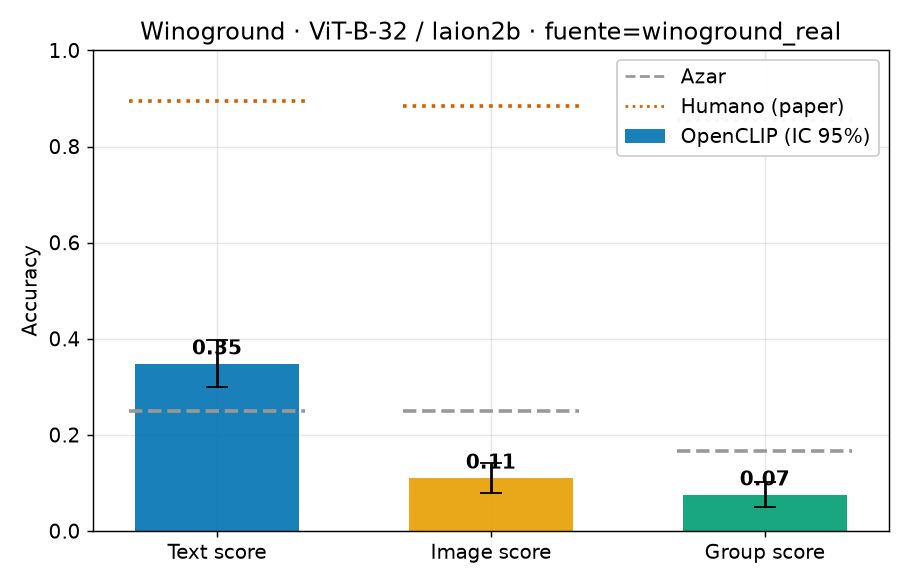

In [7]:
from IPython.display import Image, display
display(Image(filename=str(ROOT/'outputs'/'figures'/'scores_vs_chance.png')))

## 6. La evidencia de la tesis: retrieval alto vs group bajo
El **mismo** modelo, sobre el **mismo** conjunto: Recall@K alto, group ≈ azar.

texto->imagen: {'R@1': 0.30375, 'R@5': 0.6675, 'R@10': 0.77375}
group score : 0.075  (azar 0.1667 )


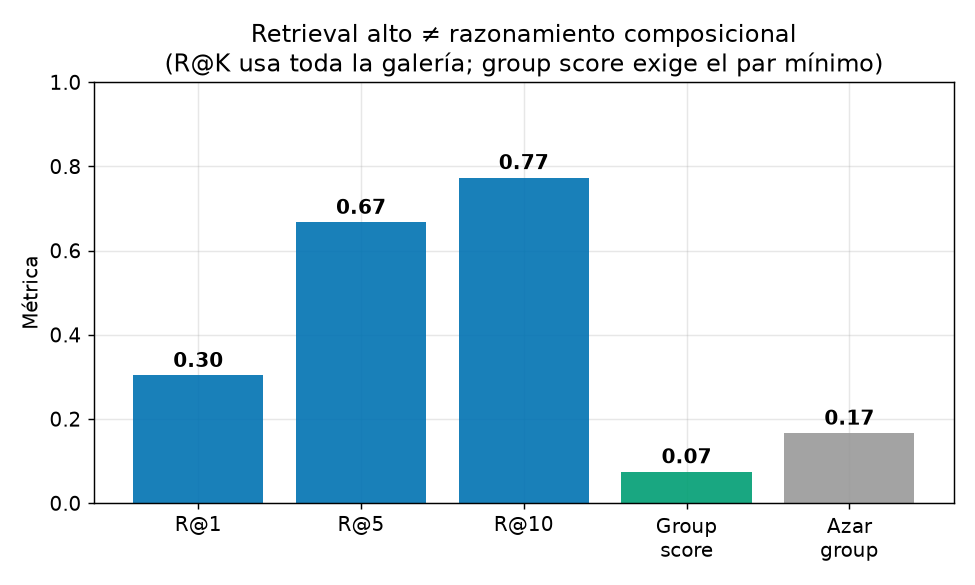

In [8]:
rg = json.loads((MET/'recall_vs_group.json').read_text())
print('texto->imagen:', {k:v for k,v in rg['text_to_image_recall'].items() if k.startswith('R@')})
print('group score :', rg['winoground_group_score'], ' (azar', rg['chance_group'], ')')
display(Image(filename=str(ROOT/'outputs'/'figures'/'recall_vs_group.png')))

## 7. ¿Qué tipo de error? ¿Usa la imagen?
Por tag (Object/Relation/Both) vemos *dónde* falla; la prueba de ceguera (permutar imágenes) confirma que **sí usa la imagen**.

In [9]:
display(pd.read_csv(MET/'by_tag.csv'))
b = json.loads((MET/'blindness.json').read_text())
print('real     :', {k:round(v,3) for k,v in b['real'].items() if 'score' in k})
print('permutado:', {k:round(v,3) for k,v in b['permuted_images'].items() if 'score' in k})

,tag,text,image,group,n
0,Relation,0.304721,0.090129,0.047210,233
1,Object,0.390071,0.106383,0.085106,141
2,Both,0.500000,0.307692,0.269231,26


real     : {'text_score': 0.347, 'image_score': 0.11, 'group_score': 0.075}
permutado: {'text_score': 0.135, 'image_score': 0.035, 'group_score': 0.015}


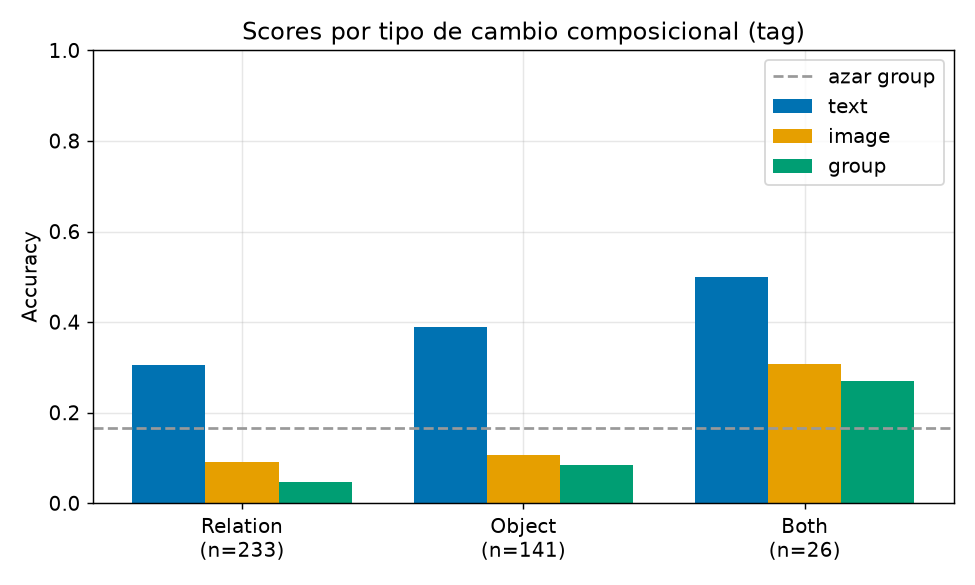

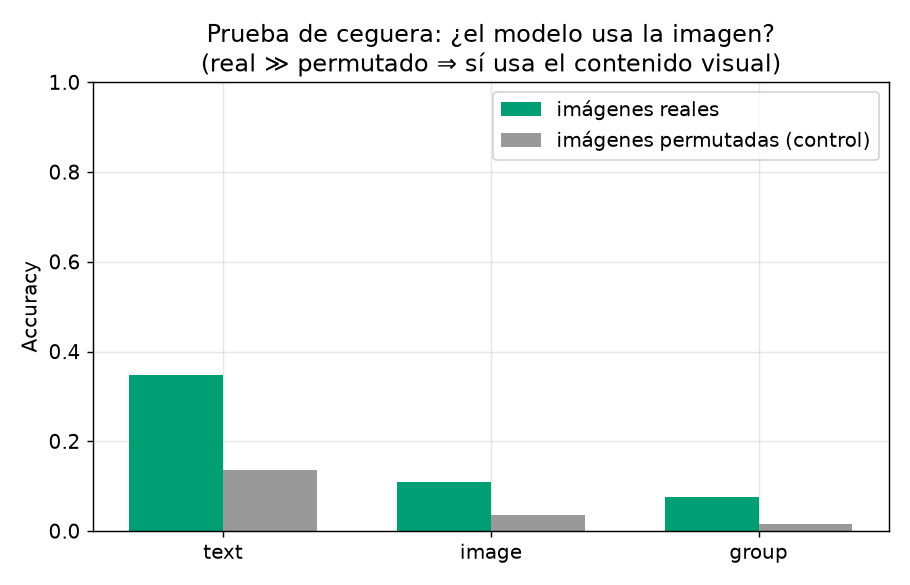

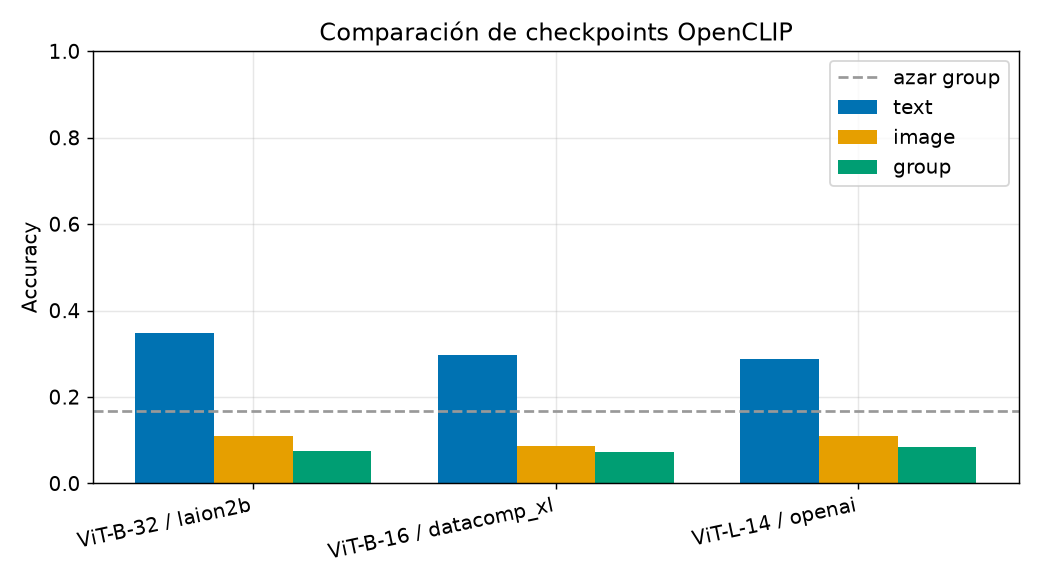

In [10]:
for n in ['by_tag.png','blindness.png','checkpoint_comparison.png']:
    display(Image(filename=str(ROOT/'outputs'/'figures'/n)))

## 8. Respuestas a mis cinco preguntas (sección 8.6)

**1. ¿Por qué un buen retrieval no garantiza razonamiento composicional?**
Porque miden cosas distintas. El Recall@K busca la imagen correcta en *toda* la galería (basta el contenido grueso); Winoground exige ganar el **par mínimo**, que depende del orden y la relación. Aquí: R@5=0.67 pero group=0.075. Un dual-encoder colapsa cada modalidad en un vector y compara por coseno, así que actúa como *bolsa de conceptos* (conecta con C5).

**2. ¿Cómo verifico que usa la imagen y no pistas textuales?**
Con la **prueba de ceguera**: permuto las imágenes entre ejemplos y recalculo. Los scores caen de 0.35/0.11/0.075 a 0.14/0.04/0.02. Como caen, el modelo **sí** usa la imagen; su límite es composicional, no perceptivo (conecta con C8). Además las dos captions tienen las mismas palabras: no hay atajo léxico.

**3. ¿Qué tipo de error aparece en Winoground?**
Errores de **vinculación**, no de reconocimiento. Por tag, **Relation** es lo más difícil (group ≈ 0.047). El modelo reconoce los objetos pero no los liga en la estructura correcta.

**4. ¿Cómo adapto el código para evaluar pares con cambios mínimos?**
Es lo que hace este pipeline: cada ejemplo es `(image_0, image_1, caption_0, caption_1)` con `caption_0 ↔ image_0`. Para un par nuevo, duplico una caption, **permuto dos tokens**, y aporto las dos imágenes. El scorer arma la matriz $2\times2$ y aplica las 3 reglas. Lo único nuevo frente a C10 es el scorer.

**5. ¿Qué limitación tienen las métricas automáticas aquí?**
R@K y accuracy no miden composición (necesarias, no suficientes); los scores son comparaciones estrictas, sensibles a empates y a la normalización; el azar del group es 1/6, no 1/16; y el propio benchmark tiene ítems ambiguos (Diwan et al.), así que un group bajo mezcla fallo composicional con dificultad del ítem.

## 9. Relación con los cuadernos, limitación y mejora
- **C10:** motor OpenCLIP (embeddings, coseno, checkpoints, FAISS).
- **C5:** dual-encoder vs fusión profunda — *por qué* falla la composición.
- **C8:** atención crossmodal / interpretabilidad — la prueba de ceguera.

**Limitación:** el group bajo mezcla fallo composicional con ítems ambiguos; el set curado es un proxy. **Mejora:** evaluar un cross-encoder real (C5) y re-ranking con interacción cruzada (C6).

**Conclusión:** el retrieval alto **no** implica razonamiento composicional. Medido, validado y reproducible.